In [100]:
from google.colab import files
uploaded=files.upload()

Saving stock_data.csv to stock_data (1).csv


In [101]:
!pip install pandas
import pandas as pd
df=pd.read_csv("stock_data.csv")

In [102]:
df.head()

,Date,Close,High,Low,Open,Volume
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600


In [103]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [104]:
df.tail()

,Date,Close,High,Low,Open,Volume
11100,2024-12-24,257.286652,257.296596,254.386927,254.586231,23234700
11101,2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100
11102,2024-12-27,254.685883,257.784897,252.164833,256.917949,42355300
11103,2024-12-30,251.307877,252.603281,249.863009,251.337769,35557500
11104,2024-12-31,249.534180,252.384064,248.547676,251.547039,39480700


In [105]:
df.set_index('Date',inplace=True)

Text(0, 0.5, 'High')

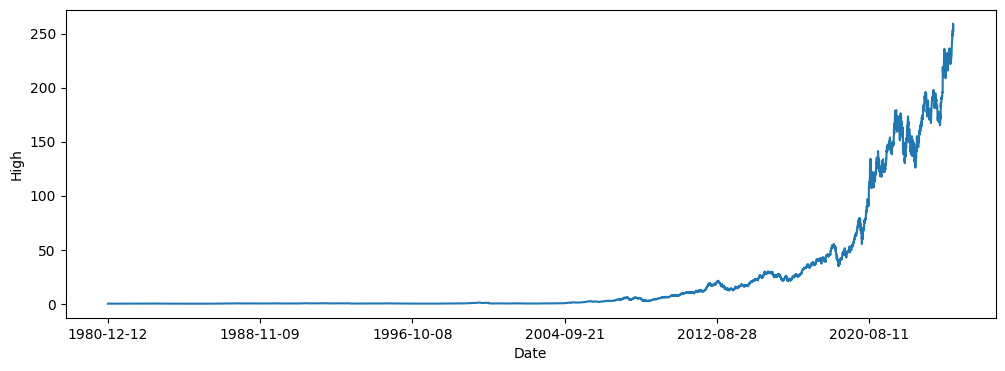

In [106]:
ax_=df['High'].plot(figsize=(12,4))
ax_.set_ylabel('High')

<Axes: title={'center': 'Rolling Variance (High)'}, xlabel='Date'>

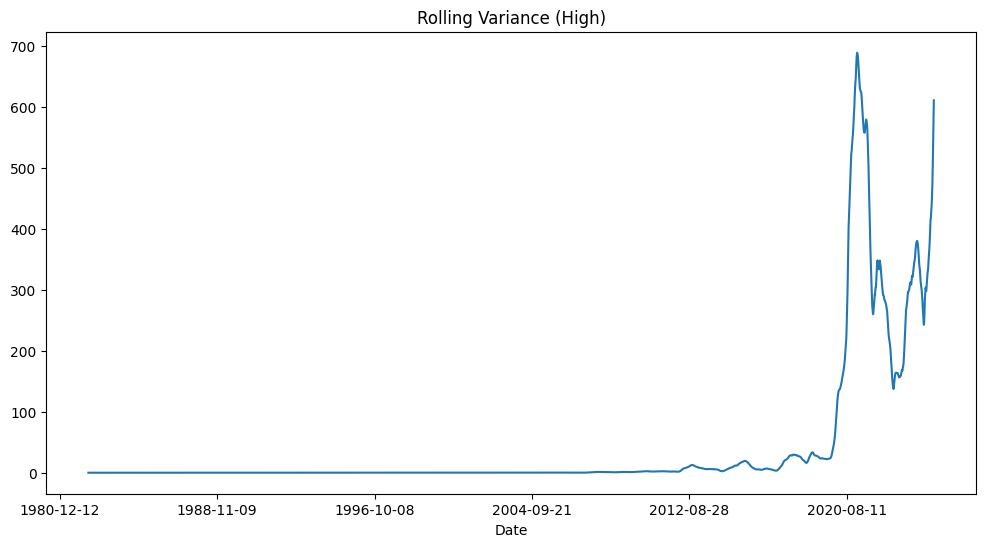

In [107]:
df["High"].rolling(365).var().plot(figsize=(12,6), title="Rolling Variance (High)")

In [108]:
df_index=df.loc['2016-08-28':'2017-08-28'].index
df_open=df.loc['2016-08-28':'2017-08-28']['Open']

In [109]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

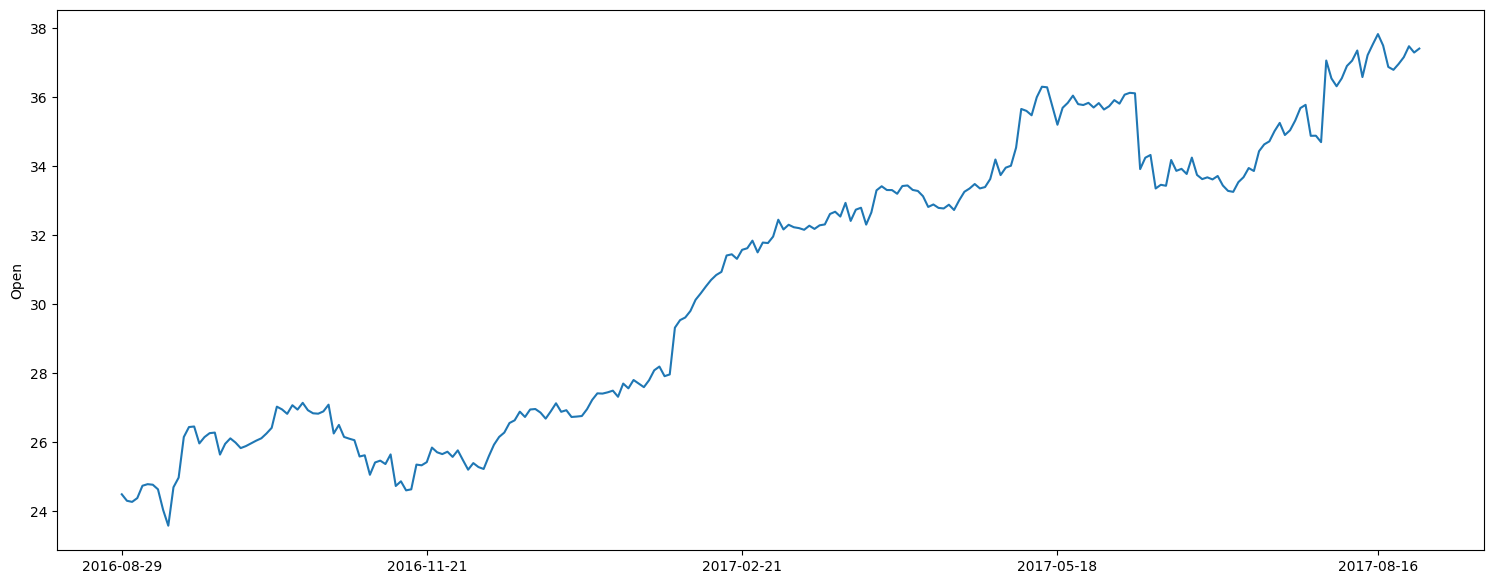

In [110]:
fig,axis=plt.subplots(figsize=(15,6))
plt.tight_layout()
axis.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 3, 5, 7, 9]))
axis.set_ylabel('Open')
axis=plt.plot(df_index,df_open)

In [111]:
df=df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11105 entries, 0 to 11104
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11105 non-null  datetime64[ns]
 1   Close   11105 non-null  float64       
 2   High    11105 non-null  float64       
 3   Low     11105 non-null  float64       
 4   Open    11105 non-null  float64       
 5   Volume  11105 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 520.7 KB


In [112]:
df=df.set_index('Date',drop=True)

TIME RESAMPLING

In [113]:
#Year End
df.resample(rule='A').min()

/tmp/ipython-input-1995752424.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').min()


,Close,High,Low,Open,Volume
Date,,,,,
1980-12-31,0.086495,0.086924,0.086495,0.086924,35750400
1981-12-31,0.048814,0.049671,0.048814,0.049242,0
1982-12-31,0.037681,0.038109,0.037681,0.038109,13596800
1983-12-31,0.061232,0.065942,0.059091,0.061232,1388800
1984-12-31,0.074934,0.077932,0.074934,0.077503,27686400
1985-12-31,0.049671,0.050527,0.049671,0.050099,21504000
1986-12-31,0.075790,0.076219,0.074506,0.075362,50176000
1987-12-31,0.140020,0.140877,0.137451,0.138308,56638400
1988-12-31,0.250851,0.255190,0.246510,0.248246,29937600


/tmp/ipython-input-3830015580.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample(rule='A').max().plot()


<Axes: xlabel='Date'>

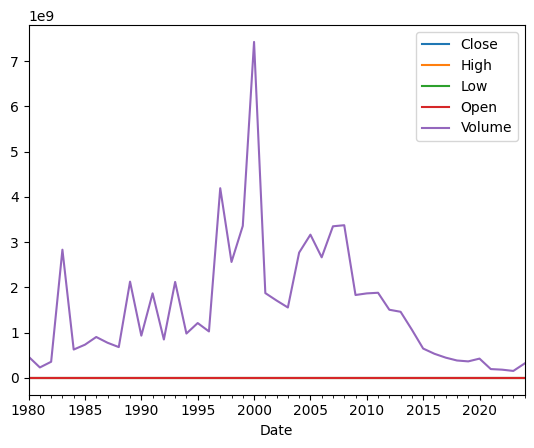

In [114]:
df.resample(rule='A').max().plot()

In [115]:
#Quaterly start
df.resample(rule='QS').max()

,Close,High,Low,Open,Volume
Date,,,,,
1980-10-01,0.123320,0.123748,0.123320,0.123320,469033600
1981-01-01,0.118182,0.119039,0.118182,0.118182,231302400
1981-04-01,0.113472,0.113901,0.113472,0.113472,149497600
1981-07-01,0.089493,0.089921,0.089493,0.089493,170464000
1981-10-01,0.078360,0.078788,0.078360,0.078360,137155200
...,...,...,...,...,...
2023-10-01,196.446808,197.944126,195.346124,196.357567,128538400
2024-01-01,193.541412,194.731348,192.708466,193.779401,136682600
2024-04-01,215.416946,218.926539,211.768157,216.331608,241805100


Text(0, 0.5, 'Quaterly Start(Open)')

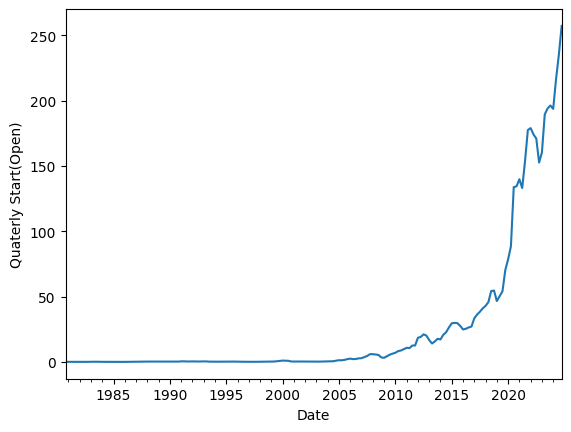

In [116]:
ax1=df.resample(rule='QS').max()['Open'].plot()
ax1.set_ylabel('Quaterly Start(Open)')

In [117]:
#Business End
df.resample(rule='BA').mean()

/tmp/ipython-input-2590551711.py:2: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  df.resample(rule='BA').mean()


,Close,High,Low,Open,Volume
Date,,,,,
1980-12-31,0.104282,0.104710,0.104282,0.104414,1.034501e+08
1981-12-31,0.083292,0.083842,0.083292,0.083549,3.239899e+07
1982-12-31,0.065575,0.066501,0.064939,0.065565,8.444667e+07
1983-12-30,0.128354,0.131278,0.125419,0.128354,1.759408e+08
1984-12-31,0.091812,0.093839,0.090270,0.092045,1.659250e+08
1985-12-31,0.069239,0.070612,0.069011,0.069871,1.805249e+08
1986-12-31,0.111196,0.112834,0.109119,0.110945,2.107637e+08
1987-12-31,0.267355,0.273549,0.261256,0.267407,2.362502e+08
1988-12-30,0.287149,0.291621,0.282665,0.287263,1.632134e+08


In [118]:
from statsmodels.tsa.stattools import adfuller

for column in df.columns:
    result = adfuller(df[column])
    print(f"ADF Test Results for {column}:")
    print(f"  ADF Statistic: {result[0]}")
    print(f"  P-value: {result[1]}")
    if result[1]<= 0.05:
     print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary")

ADF Test Results for Close:
  ADF Statistic: 4.840870595769048
  P-value: 1.0
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary
ADF Test Results for High:
  ADF Statistic: 5.051611186160291
  P-value: 1.0
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary
ADF Test Results for Low:
  ADF Statistic: 5.055252341747127
  P-value: 1.0
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary
ADF Test Results for Open:
  ADF Statistic: 4.87818926648367
  P-value: 1.0
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary
ADF Test Results for Volume:
  ADF Statistic: -5.404187790214555
  P-value: 3.319273915702232e-06
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [119]:
df['Close_diff'] = df['Close'].diff(periods=1)
df['Close_diff'].head()

,Close_diff
Date,
1980-12-12,NaN
1980-12-15,-0.005138
1980-12-16,-0.006851
1980-12-17,0.002141
1980-12-18,0.002570


In [120]:
result = adfuller(df['Close_diff'].dropna())
print("ADF Test Results for Close_diff:")
print(f"  ADF Statistic: {result[0]}")
print(f"  P-value: {result[1]}")
if result[1]<= 0.05:
     print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary")

ADF Test Results for Close_diff:
  ADF Statistic: -17.568182365544207
  P-value: 4.064176777815759e-30
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [121]:
df['High_diff'] = df['High'].diff(periods=1).dropna()
df['High_diff'].head()

,High_diff
Date,
1980-12-12,NaN
1980-12-15,-0.005138
1980-12-16,-0.006851
1980-12-17,0.002141
1980-12-18,0.002570


In [122]:
result_ = adfuller(df['High_diff'].dropna())
print("ADF Test Results for Close_diff:")
print(f"  ADF Statistic: {result_[0]}")
print(f"  P-value: {result_[1]}")
if result_[1]<= 0.05:
     print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary")

ADF Test Results for Close_diff:
  ADF Statistic: -17.9974235151845
  P-value: 2.741431153748962e-30
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [123]:
# Define the features you want to check
features = ["Open", "Low" ]

# Differencing period (can change to seasonal_diff like 12, 30, etc.)
diff_period = 1

for col in features:
    diff_col = f"{col}_diff"
    df[diff_col] = df[col].diff(periods=diff_period)

    # Drop NaN values for ADF test
    series = df[diff_col].dropna()

    # Perform ADF test
    result1 = adfuller(series)
    print(f"\nADF Test Results for {diff_col}:")
    print(f"  ADF Statistic: {result1[0]}")
    print(f"  P-value: {result1[1]}")

    if result1[1] <= 0.05:
        print("✅ Strong evidence against null hypothesis is Stationary")
    else:
        print("⚠️ Weak evidence against null hypothesis is Non-stationary")



ADF Test Results for Open_diff:
  ADF Statistic: -17.888490802850882
  P-value: 2.9838566925199753e-30
✅ Strong evidence against null hypothesis is Stationary

ADF Test Results for Low_diff:
  ADF Statistic: -17.685722621621977
  P-value: 3.591153142952631e-30
✅ Strong evidence against null hypothesis is Stationary


In [124]:
df

,Close,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff
Date,,,,,,,,,
1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN
1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-0.004710,-0.005138
1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-0.006851,-0.006851
1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,0.001713,0.002141
1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,0.002570,0.002570
...,...,...,...,...,...,...,...,...,...
2024-12-24,257.286652,257.296596,254.386927,254.586231,23234700,2.919617,2.550915,0.717428,1.833461
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100,0.817078,1.883330,2.690447,2.331735
2024-12-27,254.685883,257.784897,252.164833,256.917949,42355300,-3.417847,-1.395029,-0.358730,-4.553829


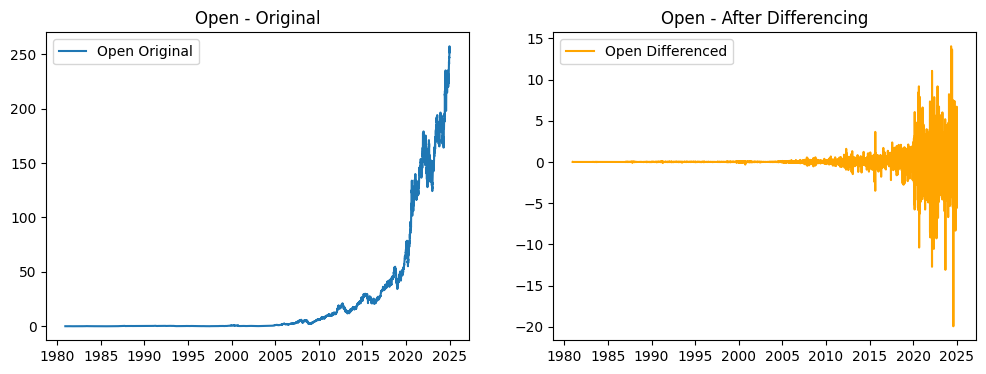

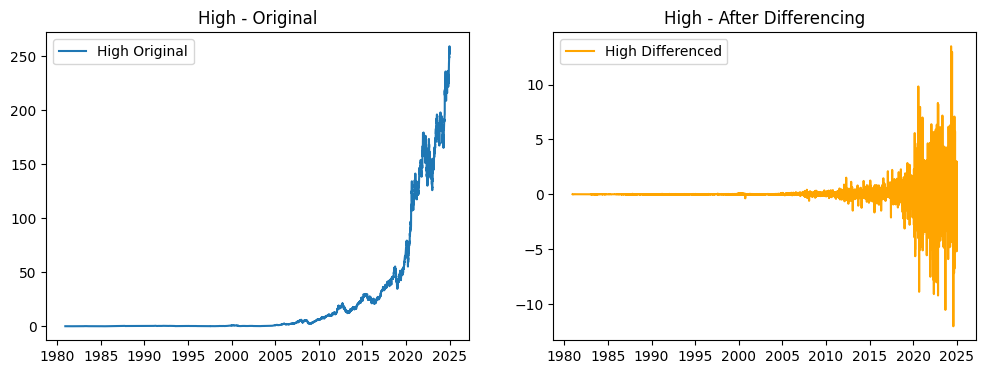

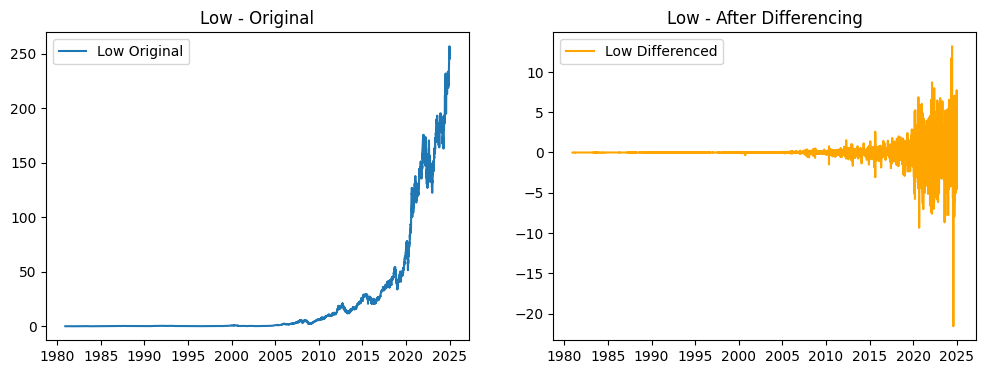

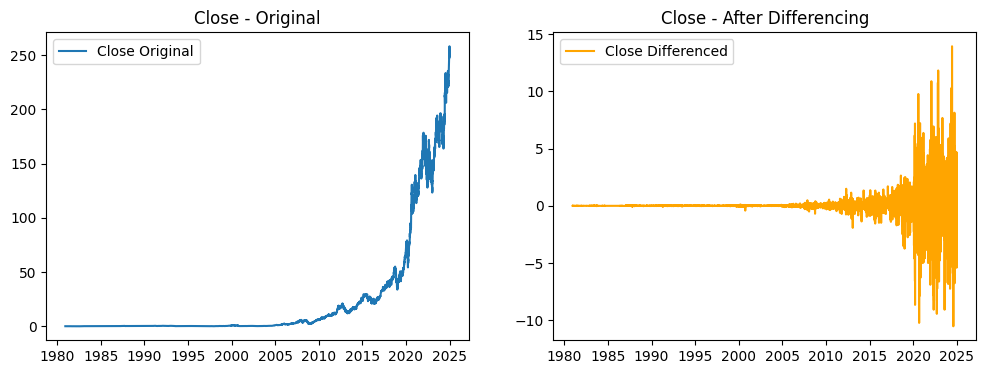

In [125]:
import matplotlib.pyplot as plt

features = ["Open", "High", "Low", "Close"]

for col in features:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(df[col], label=f"{col} Original")
    plt.title(f"{col} - Original")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(df[f"{col}_diff"], label=f"{col} Differenced", color='orange')
    plt.title(f"{col} - After Differencing")
    plt.legend()

    plt.show()


In [126]:
df.head(20)

,Close,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff
Date,,,,,,,,,
1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN
1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-4.709839e-03,-0.005138
1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-6.851440e-03,-0.006851
1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,1.712640e-03,0.002141
1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,2.569810e-03,0.002570
1980-12-19,0.096772,0.097200,0.096772,0.096772,48630400,0.005566,0.005566,5.566172e-03,0.005566
1980-12-22,0.101482,0.101911,0.101482,0.101482,37363200,0.004710,0.004711,4.709885e-03,0.004710
1980-12-23,0.105764,0.106193,0.105764,0.105764,46950400,0.004282,0.004282,4.282422e-03,0.004282
1980-12-24,0.111331,0.111759,0.111331,0.111331,48003200,0.005566,0.005566,5.566224e-03,0.005566


For Open_diff :


<Figure size 1200x400 with 0 Axes>

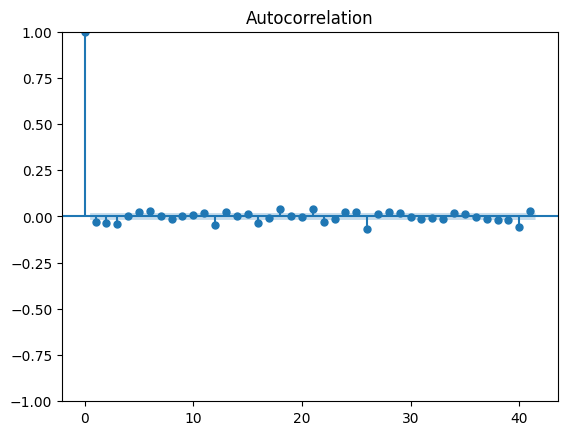

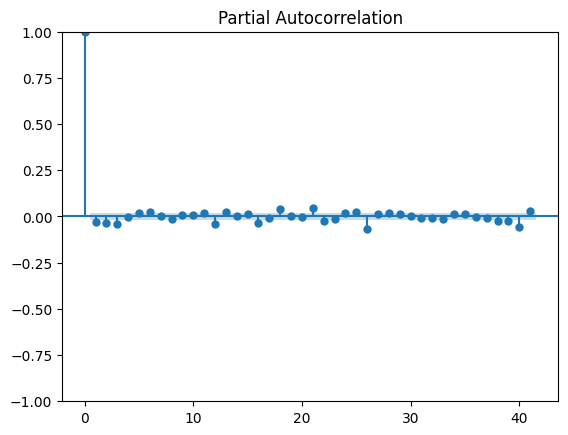

For High_diff :


<Figure size 1200x400 with 0 Axes>

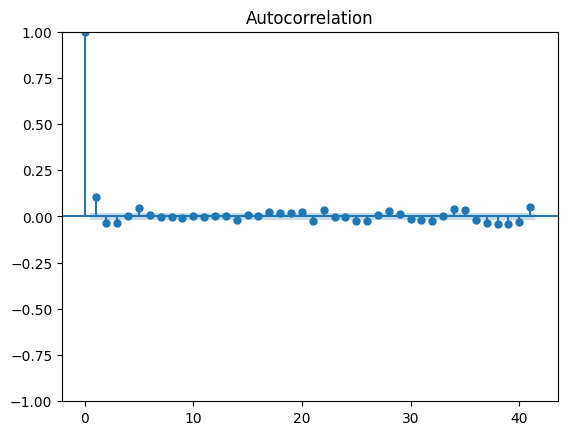

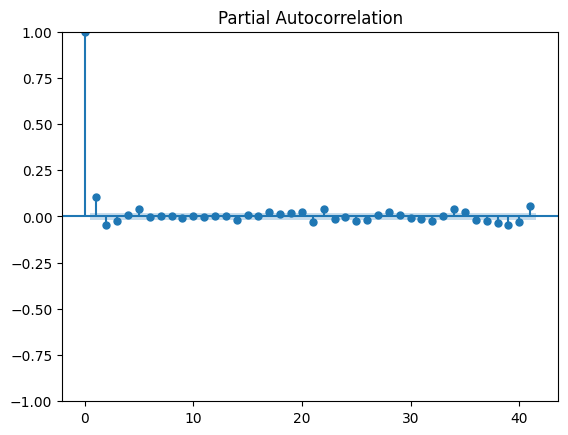

For Low_diff :


<Figure size 1200x400 with 0 Axes>

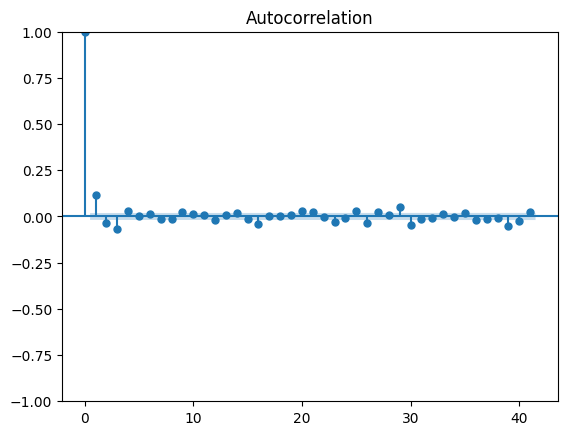

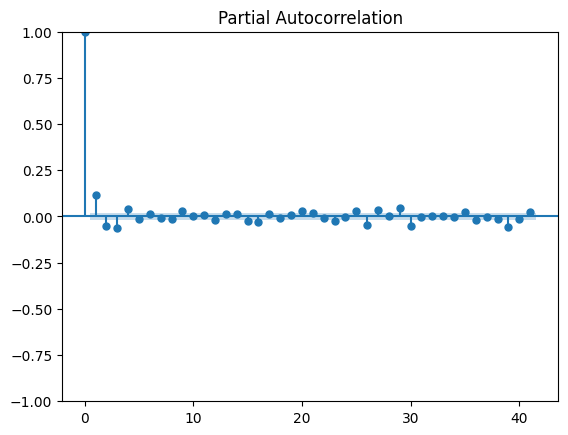

For Close_diff :


<Figure size 1200x400 with 0 Axes>

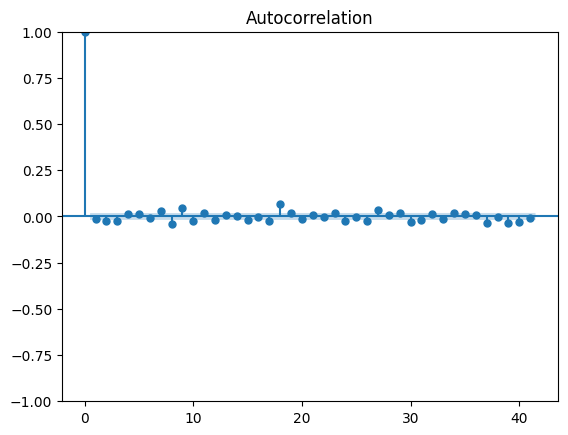

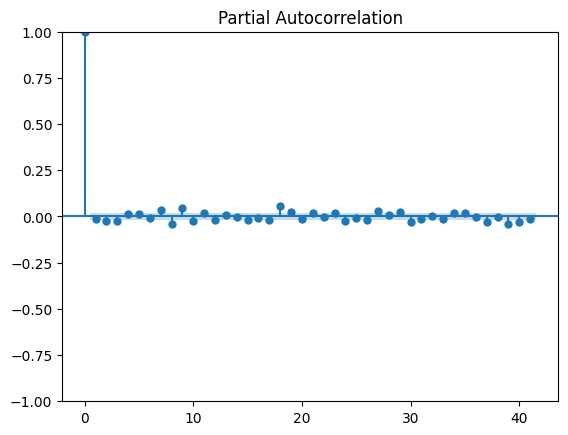

In [127]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

features = ["Open_diff", "High_diff", "Low_diff", "Close_diff"]

for col in features:
    plt.figure(figsize=(12,4))
    print(f"For {col} :")
    cf = plot_acf(df[f"{col}"].dropna())
    plt.show(cf)

    cf_=plot_pacf(df[f"{col}"].dropna())
    plt.show(cf_)

In [128]:
from statsmodels.tsa.arima.model import ARIMA

In [129]:
series=df.loc['2004-09-21':]['Close']

In [130]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

In [131]:
model = ARIMA(series, order=(0,1,0))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5105
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8800.630
Date:                Wed, 03 Sep 2025   AIC                          17603.261
Time:                        07:25:23   BIC                          17609.798
Sample:                             0   HQIC                         17605.550
                               - 5105                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.8416      0.012    148.326      0.000       1.817       1.866
Ljung-Box (L1) (Q):                   0.73   Jarque-Bera (JB):             49525.89
Prob(Q):                              0.39   Pr

In [132]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


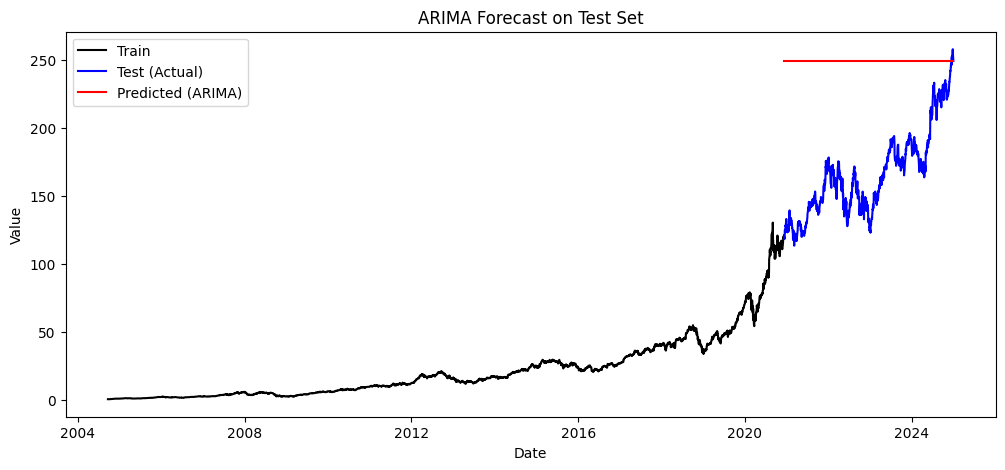

In [133]:
# Plot Train vs Test vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train", color="black")
plt.plot(test.index, test, label="Test (Actual)", color="blue")
plt.plot(test.index, forecast, label="Predicted (ARIMA)", color="red")
plt.title("ARIMA Forecast on Test Set")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

In [134]:
df['Close_1diff'] = df['Close']-df['Close'].shift(18)

<Axes: xlabel='Date'>

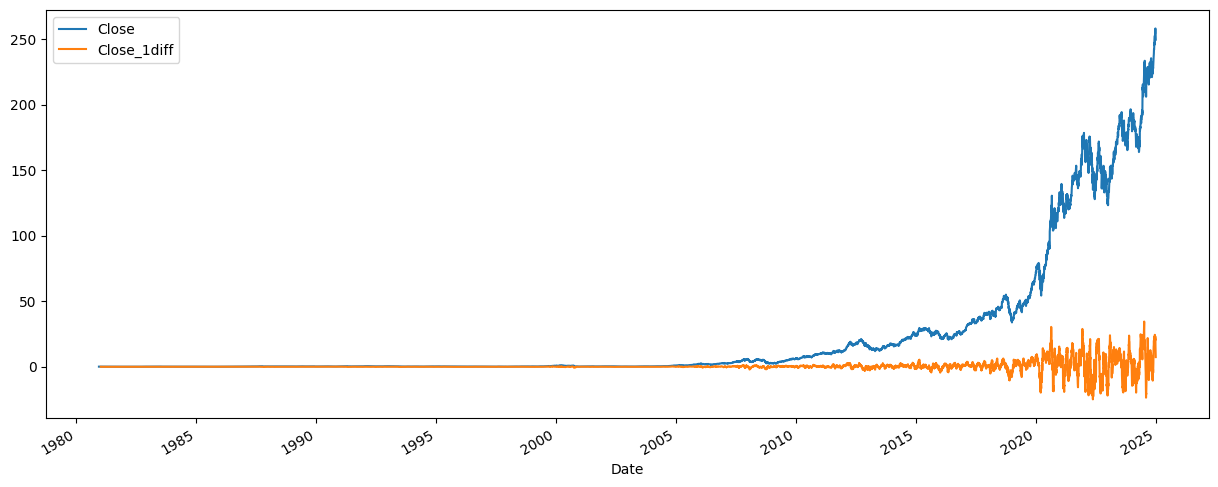

In [135]:
df[['Close','Close_1diff']].plot(figsize=(15,6))

SARIMA MODEL

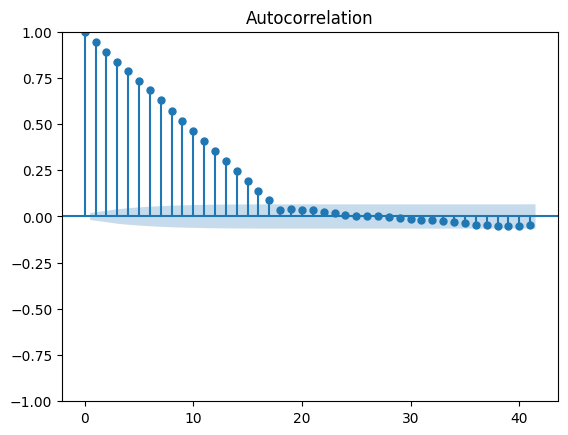

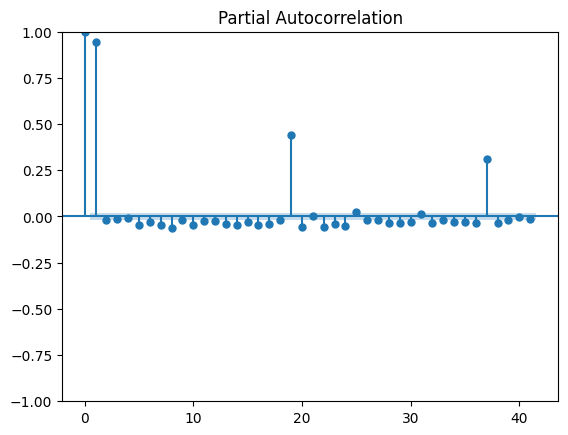

In [136]:
cf = plot_acf(df['Close_1diff'].dropna())
plt.show(cf)

cf_=plot_pacf(df['Close_1diff'].dropna())
plt.show(cf_)

In [137]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1,0,17), seasonal_order=(0,1,0,18))
model_fit_sarima = model.fit(disp=False)
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 5105
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8800.630
Date:                Wed, 03 Sep 2025   AIC                          17603.261
Time:                        07:28:23   BIC                          17609.798
Sample:                             0   HQIC                         17605.550
                               - 5105                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.8416      0.012    148.326      0.000       1.817       1.866
Ljung-Box (L1) (Q):                   0.73   Jarque-Bera (JB):             49525.89
Prob(Q):                              0.39   Pr

In [138]:
forecast = model_fit_sarima.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [139]:
# Ensure forecast index = test index
forecast = pd.Series(forecast.values, index=test.index)

# Now recalculate metrics safely
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

# Avoid division by zero for MAPE
mape = np.mean(np.abs((test - forecast) / test.replace(0, np.nan))) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 55.70
MAE: 46.00
MAPE: 25.24%


<Axes: xlabel='Date'>

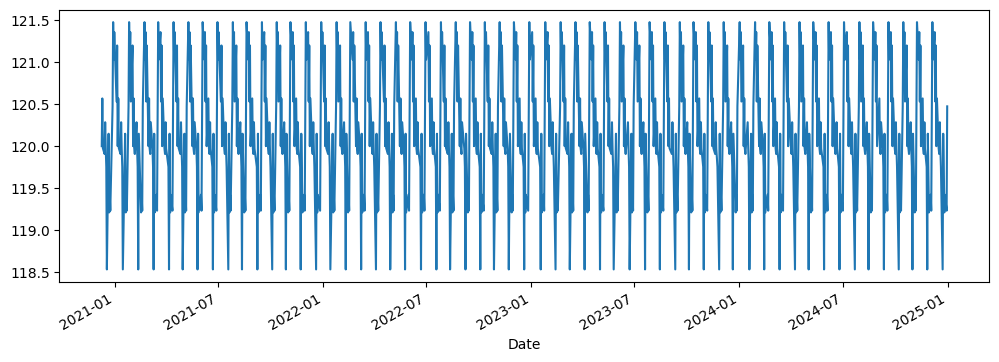

In [140]:
forecast.plot(figsize=(12,4))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


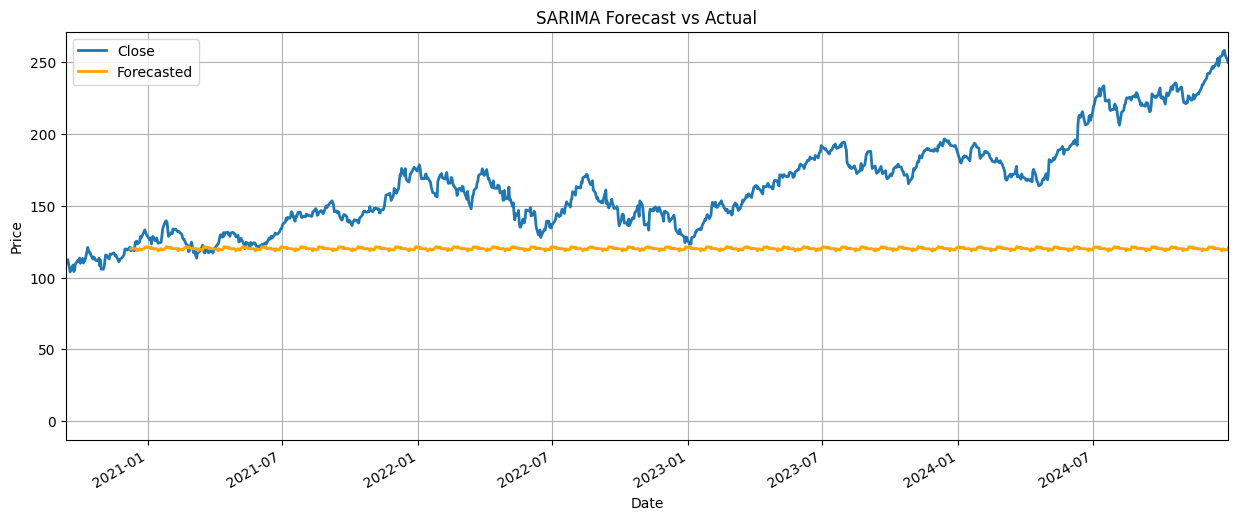

In [141]:
import matplotlib.pyplot as plt

# Forecast as a Series
forecast = model_fit_sarima.forecast(steps=len(test))

# Align indices with test data
forecast.index = test.index

# Plot
plt.figure(figsize=(15,6))
df['Close'].plot(xlim=('2020-09-12','2024-12-31'),linewidth=2)
forecast.plot(label='Forecasted', linewidth=2, color='orange')

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

<Axes: xlabel='Date'>

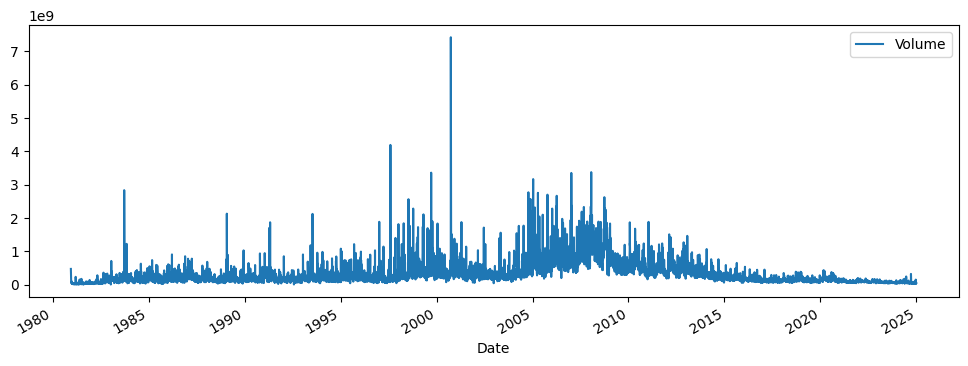

In [142]:
df[['Volume']].plot(figsize=(12,4))

/tmp/ipython-input-2028406033.py:1: FutureWarning: 'BA' is deprecated and will be removed in a future version, please use 'BYE' instead.
  ax=df.resample(rule='BA')['Low'].mean().plot()


Text(0, 0.5, 'Business End(Low)')

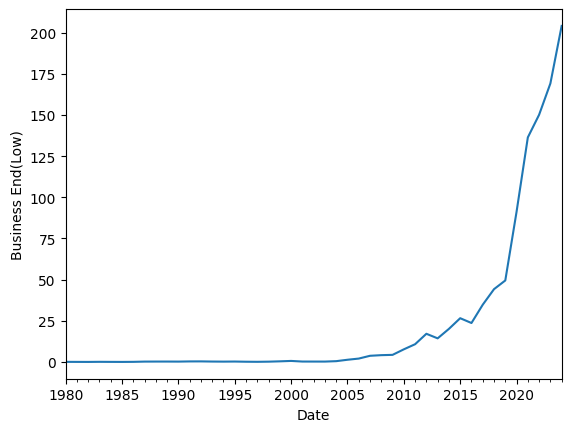

In [143]:
ax=df.resample(rule='BA')['Low'].mean().plot()
ax.set_ylabel('Business End(Low)')

/tmp/ipython-input-1297919525.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ax2=df.resample(rule='A')['Open'].mean().plot(kind='bar',figsize=(12,4))


Text(0, 0.5, 'Mean(Open)')

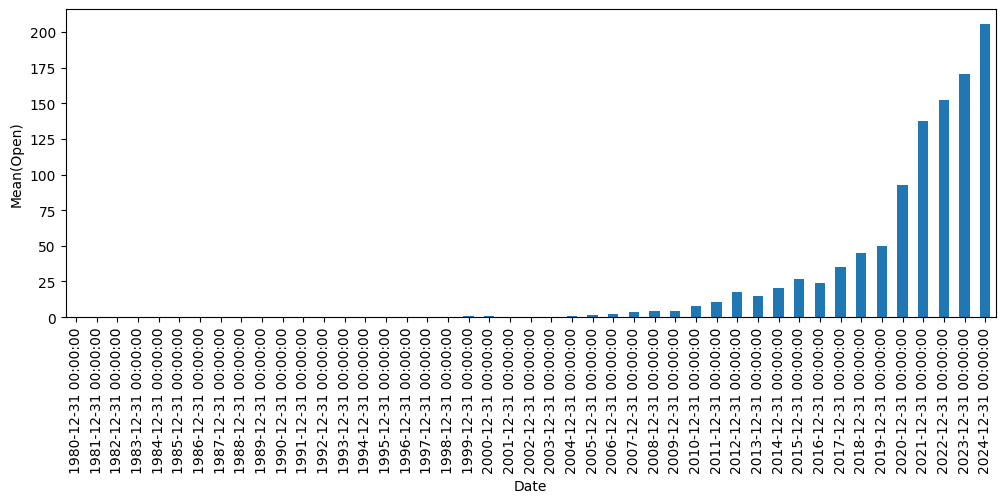

In [144]:
ax2=df.resample(rule='A')['Open'].mean().plot(kind='bar',figsize=(12,4))
ax2.set_ylabel('Mean(Open)')

In [145]:
df['Open'].rolling(6).max().head(10)

,Open
Date,
1980-12-12,NaN
1980-12-15,NaN
1980-12-16,NaN
1980-12-17,NaN
1980-12-18,NaN
1980-12-19,0.098485
1980-12-22,0.101482
1980-12-23,0.105764
1980-12-24,0.111331


In [146]:
df['Open:30 days rolling']=df['Open'].rolling(30).mean()
df.head(31)

,Close,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff,Close_1diff,Open:30 days rolling
Date,,,,,,,,,,,
1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN,NaN,NaN
1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-4.709839e-03,-0.005138,NaN,NaN
1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-6.851440e-03,-0.006851,NaN,NaN
1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,1.712640e-03,0.002141,NaN,NaN
1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,2.569810e-03,0.002570,NaN,NaN
1980-12-19,0.096772,0.097200,0.096772,0.096772,48630400,0.005566,0.005566,5.566172e-03,0.005566,NaN,NaN
1980-12-22,0.101482,0.101911,0.101482,0.101482,37363200,0.004710,0.004711,4.709885e-03,0.004710,NaN,NaN
1980-12-23,0.105764,0.106193,0.105764,0.105764,46950400,0.004282,0.004282,4.282422e-03,0.004282,NaN,NaN
1980-12-24,0.111331,0.111759,0.111331,0.111331,48003200,0.005566,0.005566,5.566224e-03,0.005566,NaN,NaN


<Axes: xlabel='Date'>

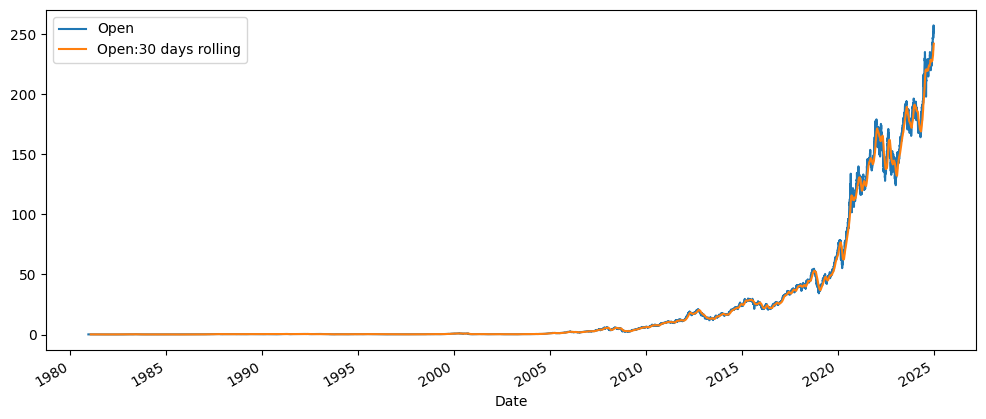

In [147]:
df[['Open','Open:30 days rolling']].plot(figsize=(12,5))

In [148]:
df['High:50 days rolling']=df['High'].rolling(50).mean()

<Axes: xlabel='Date'>

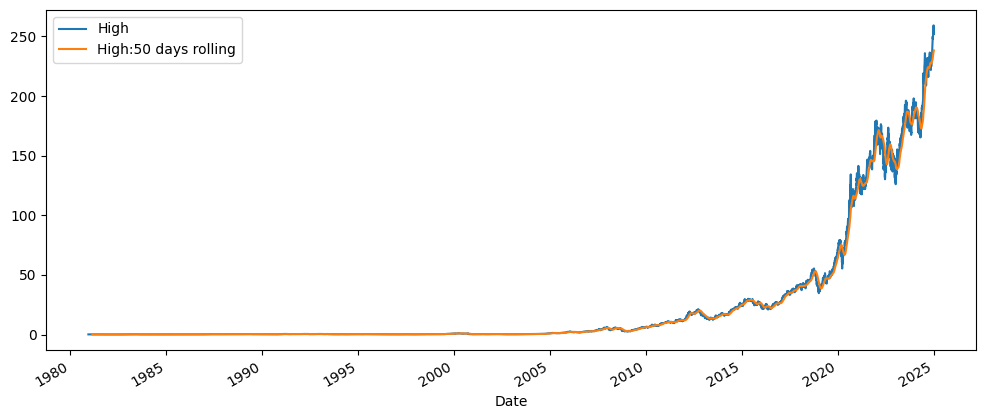

In [149]:
df[['High','High:50 days rolling']].plot(figsize=(12,5))

In [150]:
df.head()

,Close,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff,Close_1diff,Open:30 days rolling,High:50 days rolling
Date,,,,,,,,,,,,
1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-0.004710,-0.005138,NaN,NaN,NaN
1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-0.006851,-0.006851,NaN,NaN,NaN
1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,0.001713,0.002141,NaN,NaN,NaN
1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,0.002570,0.002570,NaN,NaN,NaN


FB-PROPHET MODEL

In [151]:
!pip install prophet
import prophet as fbprophet

In [152]:
from prophet import Prophet

In [153]:
df_reset= df.reset_index()

In [154]:
df_reset.head()

,Date,Close,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff,Close_1diff,Open:30 days rolling,High:50 days rolling
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-0.004710,-0.005138,NaN,NaN,NaN
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-0.006851,-0.006851,NaN,NaN,NaN
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,0.001713,0.002141,NaN,NaN,NaN
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,0.002570,0.002570,NaN,NaN,NaN


In [155]:
df_reset.rename(columns={'Date': 'ds','Close':'y'}, inplace=True)

In [156]:
df_reset.head()

,ds,y,High,Low,Open,Volume,Close_diff,High_diff,Open_diff,Low_diff,Close_1diff,Open:30 days rolling,High:50 days rolling
0,1980-12-12,0.098485,0.098913,0.098485,0.098485,469033600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1980-12-15,0.093347,0.093775,0.093347,0.093775,175884800,-0.005138,-0.005138,-0.004710,-0.005138,NaN,NaN,NaN
2,1980-12-16,0.086495,0.086924,0.086495,0.086924,105728000,-0.006851,-0.006851,-0.006851,-0.006851,NaN,NaN,NaN
3,1980-12-17,0.088636,0.089064,0.088636,0.088636,86441600,0.002141,0.002141,0.001713,0.002141,NaN,NaN,NaN
4,1980-12-18,0.091206,0.091634,0.091206,0.091206,73449600,0.002570,0.002570,0.002570,0.002570,NaN,NaN,NaN


In [157]:
df_fb=df_reset[['ds','y']]

In [158]:
df_fb

,ds,y
0,1980-12-12,0.098485
1,1980-12-15,0.093347
2,1980-12-16,0.086495
3,1980-12-17,0.088636
4,1980-12-18,0.091206
...,...,...
11100,2024-12-24,257.286652
11101,2024-12-26,258.103729
11102,2024-12-27,254.685883
11103,2024-12-30,251.307877


In [159]:
model_=Prophet()

In [160]:
df_fb=df_fb.loc[6000:]

In [161]:
model_.fit(df_fb)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmppahojo6c/yf8alexj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppahojo6c/gvdax7jw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79419', 'data', 'file=/tmp/tmppahojo6c/yf8alexj.json', 'init=/tmp/tmppahojo6c/gvdax7jw.json', 'output', 'file=/tmp/tmppahojo6c/prophet_modelkrvb2k54/prophet_model-20250903072833.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:28:33 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:28:35 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [162]:
model_.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [163]:
future_dates=model_.make_future_dataframe(periods=365)

In [164]:
future_dates

,ds
0,2004-09-21
1,2004-09-22
2,2004-09-23
3,2004-09-24
4,2004-09-27
...,...
5465,2025-12-27
5466,2025-12-28
5467,2025-12-29
5468,2025-12-30


In [165]:
prediction=model_.predict(future_dates)

In [166]:
prediction

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2004-09-21,0.752445,-7.728173,10.477180,0.752445,0.752445,0.495434,0.495434,0.495434,0.071612,0.071612,0.071612,0.423822,0.423822,0.423822,0.0,0.0,0.0,1.247879
1,2004-09-22,0.754873,-8.050370,11.413431,0.754873,0.754873,0.339068,0.339068,0.339068,-0.012951,-0.012951,-0.012951,0.352019,0.352019,0.352019,0.0,0.0,0.0,1.093941
2,2004-09-23,0.757301,-8.966493,10.954414,0.757301,0.757301,0.287273,0.287273,0.287273,-0.004803,-0.004803,-0.004803,0.292076,0.292076,0.292076,0.0,0.0,0.0,1.044574
3,2004-09-24,0.759729,-7.641960,10.769439,0.759729,0.759729,0.223509,0.223509,0.223509,-0.020153,-0.020153,-0.020153,0.243662,0.243662,0.243662,0.0,0.0,0.0,0.983238
4,2004-09-27,0.767014,-8.953205,10.631205,0.767014,0.767014,0.310376,0.310376,0.310376,0.148670,0.148670,0.148670,0.161705,0.161705,0.161705,0.0,0.0,0.0,1.077389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5465,2025-12-27,235.616883,225.901148,248.481973,230.848501,240.722895,1.235128,1.235128,1.235128,-0.091188,-0.091188,-0.091188,1.326316,1.326316,1.326316,0.0,0.0,0.0,236.852011
5466,2025-12-28,235.680137,225.952986,248.353219,230.917336,240.791064,1.092946,1.092946,1.092946,-0.091188,-0.091188,-0.091188,1.184134,1.184134,1.184134,0.0,0.0,0.0,236.773083
5467,2025-12-29,235.743391,226.015249,248.191396,230.987198,240.892776,1.183955,1.183955,1.183955,0.148670,0.148670,0.148670,1.035285,1.035285,1.035285,0.0,0.0,0.0,236.927346
5468,2025-12-30,235.806645,225.560790,248.740345,231.057061,240.991860,0.952782,0.952782,0.952782,0.071612,0.071612,0.071612,0.881170,0.881170,0.881170,0.0,0.0,0.0,236.759428


In [174]:
prediction.head()

,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
ds,,,,,,,,,,,,,,,,,,
2004-09-21,0.752445,-7.728173,10.477180,0.752445,0.752445,0.495434,0.495434,0.495434,0.071612,0.071612,0.071612,0.423822,0.423822,0.423822,0.0,0.0,0.0,1.247879
2004-09-22,0.754873,-8.050370,11.413431,0.754873,0.754873,0.339068,0.339068,0.339068,-0.012951,-0.012951,-0.012951,0.352019,0.352019,0.352019,0.0,0.0,0.0,1.093941
2004-09-23,0.757301,-8.966493,10.954414,0.757301,0.757301,0.287273,0.287273,0.287273,-0.004803,-0.004803,-0.004803,0.292076,0.292076,0.292076,0.0,0.0,0.0,1.044574
2004-09-24,0.759729,-7.641960,10.769439,0.759729,0.759729,0.223509,0.223509,0.223509,-0.020153,-0.020153,-0.020153,0.243662,0.243662,0.243662,0.0,0.0,0.0,0.983238
2004-09-27,0.767014,-8.953205,10.631205,0.767014,0.767014,0.310376,0.310376,0.310376,0.148670,0.148670,0.148670,0.161705,0.161705,0.161705,0.0,0.0,0.0,1.077389


In [176]:
test

,Close
Date,
2020-12-09,118.661942
2020-12-10,120.084557
2020-12-11,119.275803
2020-12-14,118.661942
2020-12-15,124.605774
...,...
2024-12-24,257.286652
2024-12-26,258.103729
2024-12-27,254.685883


In [178]:
# Align forecast with test dates
common_dates = prediction.index.intersection(test.index)

# Extract actuals and predictions for common dates
pred = prediction.loc[common_dates, "yhat"]
true = test.loc[common_dates]

# Metrics
rmse = np.sqrt(mean_squared_error(true, pred))
mae = mean_absolute_error(true, pred)
mape = np.mean(np.abs((true - pred) / true)) * 100

print(f"Prophet RMSE: {rmse:.2f}")
print(f"Prophet MAE: {mae:.2f}")
print(f"Prophet MAPE: {mape:.2f}%")



Prophet RMSE: 15.78
Prophet MAE: 12.78
Prophet MAPE: 7.75%


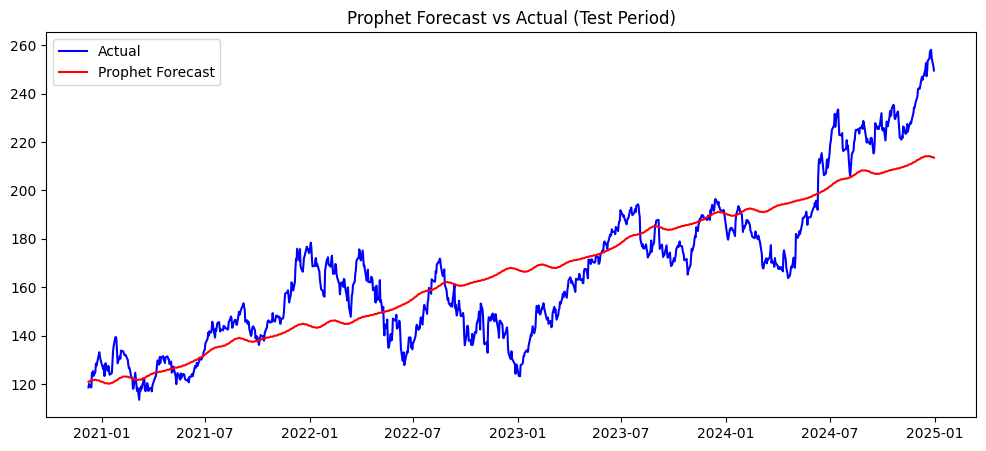

In [179]:
plt.figure(figsize=(12,5))
plt.plot(true.index, true, label="Actual", color="blue")
plt.plot(pred.index, pred, label="Prophet Forecast", color="red")
plt.title("Prophet Forecast vs Actual (Test Period)")
plt.legend()
plt.show()

In [181]:
split_ratio = 0.8
split_point = int(len(df_fb) * split_ratio)

train = df_fb.iloc[:split_point]
test  = df_fb.iloc[split_point:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())
print(test.head())

Train shape: (4084, 2)
Test shape: (1021, 2)
             ds         y
6000 2004-09-21  0.570532
6001 2004-09-22  0.554171
6002 2004-09-23  0.559425
6003 2004-09-24  0.559725
6004 2004-09-27  0.563328
              ds           y
10084 2020-12-09  118.661942
10085 2020-12-10  120.084557
10086 2020-12-11  119.275803
10087 2020-12-14  118.661942
10088 2020-12-15  124.605774


In [183]:
# Keep only predictions for dates in the test set
forecast_test = prediction[prediction.index.isin(test['ds'])].copy()

# Reset index for convenience
forecast_test = forecast_test.reset_index(drop=True)

print(forecast_test.head())
print("Shape of forecast_test:", forecast_test.shape)

        trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0  118.976424  112.424168  130.491716   118.976424   118.976424   
1  119.039678  112.358754  130.724749   119.039678   119.039678   
2  119.102932  111.680933  131.372685   119.102932   119.102932   
3  119.292694  112.013883  132.194039   119.292694   119.292694   
4  119.355948  111.966956  131.394167   119.355948   119.355948   

   additive_terms  additive_terms_lower  additive_terms_upper    weekly  \
0        1.993453              1.993453              1.993453 -0.012951   
1        2.053973              2.053973              2.053973 -0.004803   
2        2.083327              2.083327              2.083327 -0.020153   
3        2.330925              2.330925              2.330925  0.148670   
4        2.258913              2.258913              2.258913  0.071612   

   weekly_lower  weekly_upper    yearly  yearly_lower  yearly_upper  \
0     -0.012951     -0.012951  2.006404      2.006404      2.006404   
1   

In [184]:
# Align actual vs predicted
y_true = test['y'].values
y_pred = forecast_test['yhat'].values

# Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape, "%")

MAE: 12.777724206132701
RMSE: 15.784688493109073
MAPE: 7.745277030794355 %


LSTM MODEL

In [185]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [186]:
df_fb.set_index('ds',inplace=True)

In [187]:
df_fb=df_fb['2021-01-01':]

In [188]:
df_fb

,y
ds,
2021-01-04,126.096596
2021-01-05,127.655624
2021-01-06,123.358536
2021-01-07,127.567894
2021-01-08,128.669022
...,...
2024-12-24,257.286652
2024-12-26,258.103729
2024-12-27,254.685883


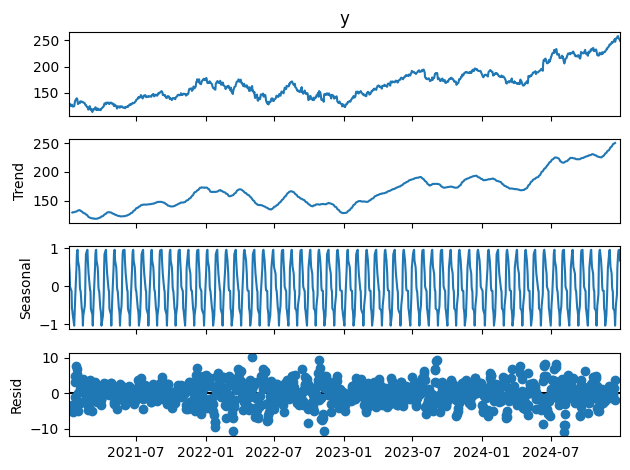

In [189]:
results = seasonal_decompose(df_fb['y'],period=17)
results.plot();

In [190]:
train = df_fb.iloc[:805]
test = df_fb.iloc[806:]

In [191]:
train.head()

,y
ds,
2021-01-04,126.096596
2021-01-05,127.655624
2021-01-06,123.358536
2021-01-07,127.567894
2021-01-08,128.669022


In [192]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [193]:
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [194]:
scaled_train[:10]

array([[0.15135054],
       [0.17015743],
       [0.11832074],
       [0.16909912],
       [0.18238226],
       [0.14629616],
       [0.14418019],
       [0.1687469 ],
       [0.14547309],
       [0.12466803]])

In [195]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [196]:
n_input = 3
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

X,y = generator[0]
print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.15135054 0.17015743 0.11832074]
Predict this y: 
 [[0.16909912]]


In [197]:
X.shape

(1, 3, 1)

In [198]:
n_input = 30
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)

In [199]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

In [201]:
# define model
model = Sequential()
model.add(LSTM(100, activation='relu',return_sequences=True,input_shape=(n_input, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [202]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

In [203]:
model.fit(generator,epochs=25)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


775/775 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - loss: 0.0255
Epoch 2/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 47s 36ms/step - loss: 0.0053
Epoch 3/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 0.0033
Epoch 4/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0023
Epoch 5/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0020
Epoch 6/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0017
Epoch 7/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - loss: 0.0017
Epoch 8/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0015
Epoch 9/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - loss: 0.0017
Epoch 10/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - loss: 0.0015
Epoch 11/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0013
Epoch 12/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - loss: 0.0012
Epoch 13/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - loss: 0.0014
Epoch 14/25
775/775 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - loss: 0.0013
Epoch 15/25
775/775 ━━━━━━━━━━━━━━━━━━━━

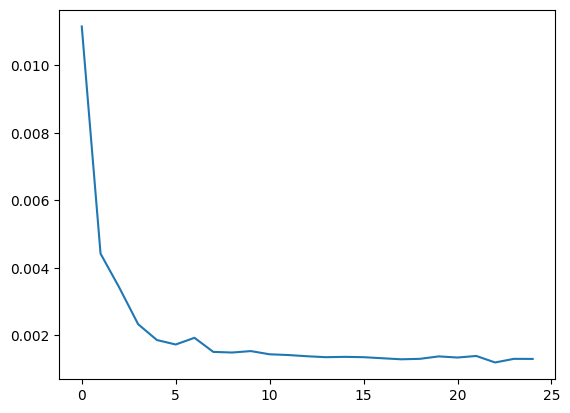

In [204]:
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

In [205]:
last_train_batch = scaled_train[-30:]
last_train_batch = last_train_batch.reshape((1, n_input, n_features))
model.predict(last_train_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step


array([[0.6764977]], dtype=float32)

In [206]:
scaled_test[0]

array([0.73916619])

In [207]:
test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):

    # get the prediction value for the first batch
    current_pred = model.predict(current_batch)[0]

    # append the prediction into the array
    test_predictions.append(current_pred)

    # use the prediction to update the batch and remove the first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

In [208]:
test_predictions

[array([0.6764977], dtype=float32),
 array([0.65510184], dtype=float32),
 array([0.6343733], dtype=float32),
 array([0.614021], dtype=float32),
 array([0.5942643], dtype=float32),
 array([0.57517445], dtype=float32),
 array([0.55673265], dtype=float32),
 array([0.53890204], dtype=float32),
 array([0.52164215], dtype=float32),
 array([0.5049322], dtype=float32),
 array([0.48880228], dtype=float32),
 array([0.4732201], dtype=float32),
 array([0.45818654], dtype=float32),
 array([0.44357094], dtype=float32),
 array([0.42929223], dtype=float32),
 array([0.41538668], dtype=float32),
 array([0.40186885], dtype=float32),
 array([0.38874495], dtype=float32),
 array([0.37601686], dtype=float32),
 array([0.36368203], dtype=float32),
 array([0.35173488], dtype=float32),
 array([0.3397456], dtype=float32),
 array([0.3276888], dtype=float32),
 array([0.31566733], dtype=float32),
 array([0.3037276], dtype=float32),
 array([0.29189193], dtype=float32),
 array([0.28017175], dtype=float32),
 array([0.2

In [209]:
test.head()

,y
ds,
2024-03-19,174.824554
2024-03-20,177.396088
2024-03-21,170.148132
2024-03-22,171.051666
2024-03-25,169.631866


In [210]:
test_predictions = np.array(test_predictions)
true_predictions = scaler.inverse_transform(test_predictions.reshape(-1, 1))

In [211]:
test['Predictions'] = true_predictions

/tmp/ipython-input-4269337381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


/tmp/ipython-input-1103562314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


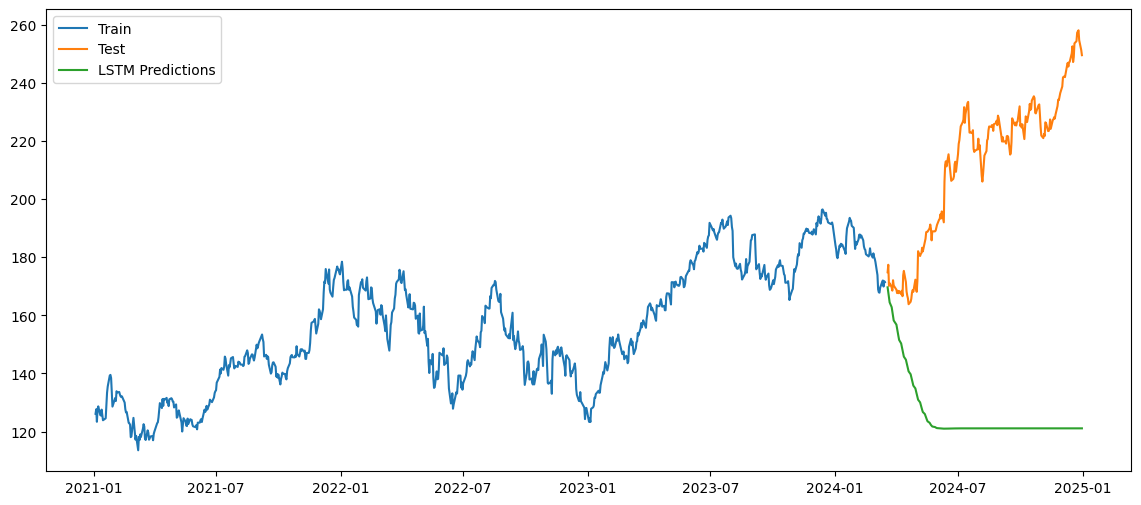

In [212]:
test['Predictions'] = true_predictions
plt.figure(figsize=(14,6))
plt.plot(train.index, scaler.inverse_transform(scaled_train), label="Train")
plt.plot(test.index, test['y'], label="Test")
plt.plot(test.index, test['Predictions'], label="LSTM Predictions")
plt.legend()
plt.show()